# Pairwise Error Correlation Matrix

Purpose: Identify models with different error patterns so that a hybrid/agent solution can maximize accuracy.

In [1]:
!pip install pandas seaborn matplotlib -q

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import difflib
from typing import Set, Dict

### Helper functions

In [3]:
def get_error_tokens(reference_text: str, model_text: str) -> Set[str]:
    """
    Compare model output against ground truth.
    Returns a set of tokens that are missing, incorrect, or hallucinated.
    """
    ref_words = str(reference_text).split()
    model_words = str(model_text).split()

    matcher = difflib.SequenceMatcher(None, ref_words, model_words)
    error_indices = set()

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag in ('replace', 'delete'):
            for i in range(i1, i2):
                error_indices.add(f"{i}_{ref_words[i]}")
        if tag in ('replace', 'insert'):
            for j in range(j1, j2):
                error_indices.add(f"halluc_{j}_{model_words[j]}")

    return error_indices


def calculate_jaccard_error_overlap(errors_a: Set[str], errors_b: Set[str]) -> float:
    """
    Calculate overlap between two models' errors.
    Formula: Intersection / Union

    0.0 = Completely different errors (Good for hybrid!)
    1.0 = Exact same errors (Redundant)
    """
    if len(errors_a) == 0 and len(errors_b) == 0:
        return 0.0

    intersection = len(errors_a.intersection(errors_b))
    union = len(errors_a.union(errors_b))

    if union == 0:
        return 0.0

    return intersection / union

### Upload files

In [4]:
import os

def load_ground_truth():
    try:
        from google.colab import files
        print("Upload ground truth file:")
        uploaded = files.upload()
        gt_filename = list(uploaded.keys())[0]

    except ImportError:
        default_path = "data/ground_truth/dataset/ground_truth.md"

        if os.path.exists(default_path):
            print(f"Using local file: {default_path}")
            gt_filename = default_path
        else:
            gt_filename = input("Enter path to ground truth file: ")

    # Read file
    with open(gt_filename, 'r', encoding='utf-8') as f:
        ground_truth = f.read()

    print(f"\nLoaded: {gt_filename}")
    print(f"Number of words: {len(ground_truth.split())}")

    return ground_truth, gt_filename


ground_truth, gt_filename = load_ground_truth()


Upload ground truth file:


Saving ground_truth.md to ground_truth.md

Loaded: ground_truth.md
Number of words: 29949


In [5]:
import os
import glob

print("Upload ALL models' output.md files:")

try:
    from google.colab import files
    uploaded_models = files.upload()

except ImportError:
    # Local execution
    folder_path = "data/models_outputs"
    file_paths = glob.glob(os.path.join(folder_path, "*.md"))

    uploaded_models = {}
    for path in file_paths:
        with open(path, 'rb') as f:  # note: 'rb' to match Colab behavior
            uploaded_models[os.path.basename(path)] = f.read()

model_outputs = {}
model_lengths = {}

for filename, content in uploaded_models.items():
    model_name = filename.replace('.md', '').replace('_output', '').replace('output_', '')
    text = content.decode('utf-8')
    model_outputs[model_name] = text
    model_lengths[model_name] = len(text.split())

print(f"\nTotal of {len(model_outputs)} models loaded")

Upload ALL models' output.md files:


Saving chandra_output.md to chandra_output.md
Saving deepseek_ocr_output.md to deepseek_ocr_output.md
Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving doctr_output.md to doctr_output.md
Saving easyocr_output.md to easyocr_output.md
Saving florence2_output.md to florence2_output.md
Saving gemini2.5_output.md to gemini2.5_output.md
Saving GLM_ocr_output.md to GLM_ocr_output.md
Saving haiku_output.md to haiku_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving landingai_output.md to landingai_output.md
Saving latex_output.md to latex_output.md
Saving lightonocr_output.md to lightonocr_output.md
Saving llamaindex.md to llamaindex.md
Saving llamaparse_output.md to llamaparse_output.md
Saving mistral_output.md to mistral_output.md
Saving nemotron_ocr_output.md to nemotron_ocr_output.md
Saving paddle_ocr_output.md to paddle_ocr_output.md
Saving pdfplumber_output.md to pdfplumber_output.md
Saving Qianfan_ocr_output.md to 

In [6]:
for model_name, length in model_lengths.items():
    print(f" {model_name}: {length} ord")

 chandra: 29094 ord
 deepseek_ocr: 24317 ord
 deepseek_ocr2: 25008 ord
 docling: 26707 ord
 doctr: 25140 ord
 easyocr: 27408 ord
 florence2: 12545 ord
 gemini2.5: 27526 ord
 GLM_ocr: 49990 ord
 haiku: 16646 ord
 hunyuan: 29437 ord
 landingai: 100149 ord
 latex: 27587 ord
 lightonocr: 28724 ord
 llamaindex: 30393 ord
 llamaparse: 27801 ord
 mistral: 31308 ord
 nemotron_ocr: 23331 ord
 paddle_ocr: 27219 ord
 pdfplumber: 27593 ord
 Qianfan_ocr: 12738 ord
 qwen25: 32179 ord
 sonnet4: 27734 ord
 surya: 36234 ord
 tesseract: 28430 ord
 trocr: 32389 ord


### Calculate the matrix


In [7]:
# Extract errors for each model
model_errors = {}
for name, text in model_outputs.items():
    model_errors[name] = get_error_tokens(ground_truth, text)
    print(f"{name}: {len(model_errors[name])} errors found")

chandra: 7109 errors found
deepseek_ocr: 11674 errors found
deepseek_ocr2: 11735 errors found
docling: 14908 errors found
doctr: 41021 errors found
easyocr: 34445 errors found
florence2: 41376 errors found
gemini2.5: 32995 errors found
GLM_ocr: 36209 errors found
haiku: 28959 errors found
hunyuan: 6980 errors found
landingai: 91598 errors found
latex: 26230 errors found
lightonocr: 12043 errors found
llamaindex: 4774 errors found
llamaparse: 29456 errors found
mistral: 35195 errors found
nemotron_ocr: 46178 errors found
paddle_ocr: 33228 errors found
pdfplumber: 32956 errors found
Qianfan_ocr: 24203 errors found
qwen25: 19410 errors found
sonnet4: 20021 errors found
surya: 40445 errors found
tesseract: 25731 errors found
trocr: 25014 errors found


In [8]:
model_names = list(model_errors.keys())
matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for a in model_names:
    for b in model_names:
        matrix.loc[a, b] = calculate_jaccard_error_overlap(model_errors[a], model_errors[b])

### Visualization

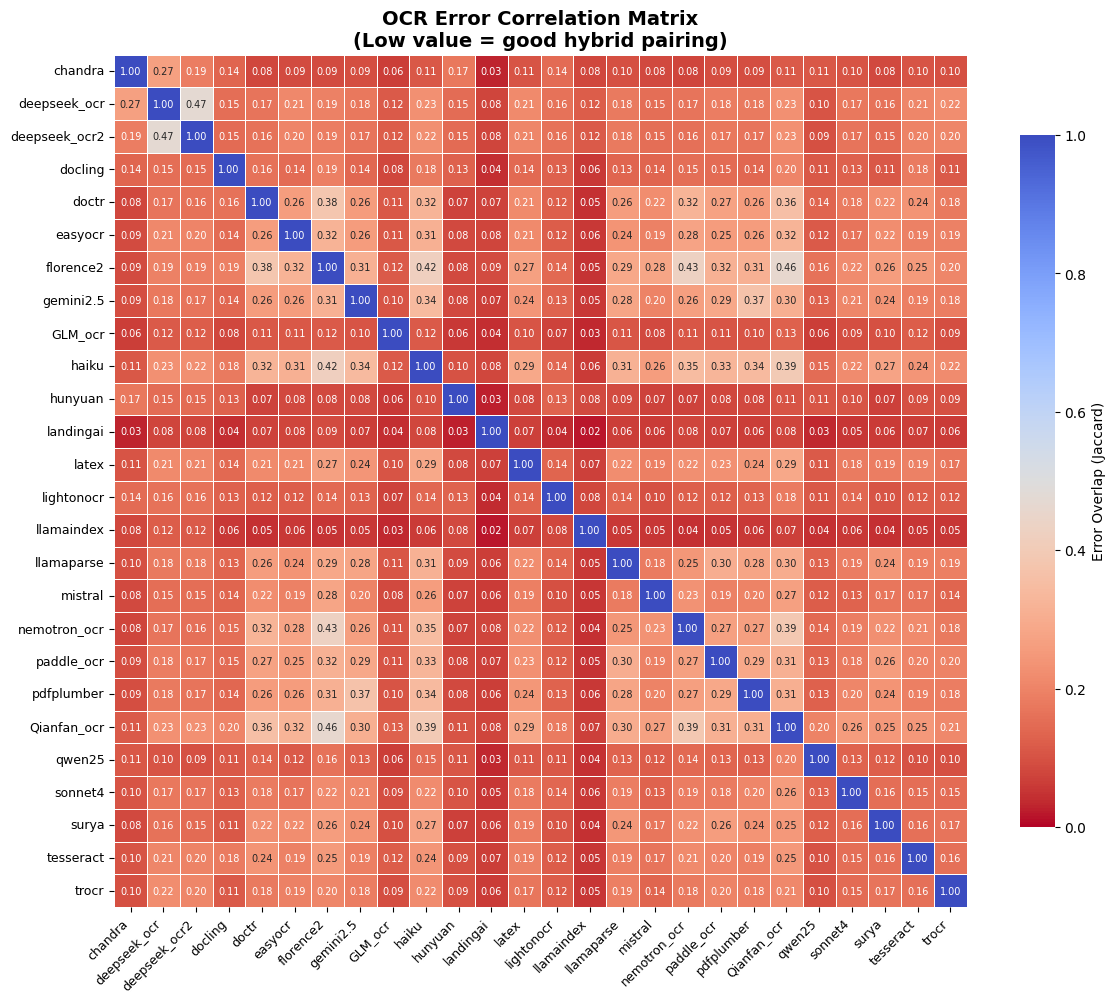

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Error Overlap (Jaccard)', 'shrink': 0.8},
    ax=ax
)

# Rotera labels för läsbarhet
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

ax.set_title("OCR Error Correlation Matrix\n(Low value = good hybrid pairing)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('error_matrix.png', dpi=150, bbox_inches='tight')
plt.show()